In [51]:
import pandas as pd
from datasets import load_dataset
import seaborn as sns
sns.set_theme(style="white", palette="pastel")
import matplotlib.pyplot as plt
from IPython.display import display

#Chemical libraries
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors

In [2]:
raw_data = pd.read_csv("hf://datasets/openadmet/openadmet-expansionrx-challenge-train-data/expansion_data_train_raw.csv")

In [3]:
raw_data.head()

,Molecule Name,SMILES,LogD,KSOL,HLM CLint,MLM CLint,Caco-2 Permeability Papp A>B,Caco-2 Permeability Efflux,MPPB,MBPB,...,LogD modifier,KSOL modifier,HLM CLint modifier,MLM CLint modifier,Caco-2 Permeability Papp A>B modifier,Caco-2 Permeability Efflux modifier,MPPB modifier,MBPB modifier,MGMB modifier,INCHIKEY
0,E-0001321,CN1CCC[C@H]1COc1ccc(-c2nc3cc(-c4ccc5[nH]c(-c6c...,NaN,NaN,56.4,182.3,NaN,NaN,NaN,NaN,...,NaN,NaN,=,=,NaN,NaN,NaN,NaN,NaN,AELDWFGFDSTYDV-DEOSSOPVSA-N
1,E-0001780,COc1ccc2c(c1)c1cc3cnccc3c(C)c1n2C,NaN,NaN,160.4,1351.1,NaN,NaN,NaN,NaN,...,NaN,NaN,=,=,NaN,NaN,NaN,NaN,NaN,NCCOQMRIPAPGNR-UHFFFAOYSA-N
2,E-0001827,Cc1c2ccncc2cc2c3cc(OCCCN4CCN(C)CC4)ccc3n(C)c12,NaN,NaN,NaN,193.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,=,NaN,NaN,NaN,NaN,NaN,ZNTBNESSWOHBPD-UHFFFAOYSA-N
3,E-0002019,CN(C)CCCOc1ccc(-c2nc3cc(NC(=O)c4ccc5[nH]c(-c6c...,NaN,NaN,9.5,38.0,NaN,NaN,NaN,NaN,...,NaN,NaN,=,<,NaN,NaN,NaN,NaN,NaN,UYUIMPIKINVAPS-UHFFFAOYSA-N
4,E-0002036,CN(C)CCCOc1ccc2nc(-c3ccc(-c4nc5ccc(OCCCN(C)C)c...,NaN,NaN,8.6,162.0,NaN,NaN,NaN,NaN,...,NaN,NaN,<,=,NaN,NaN,NaN,NaN,=,DTYIIQCGXIIFFU-UHFFFAOYSA-N


,LogD,KSOL,HLM CLint,MLM CLint,Caco-2 Permeability Papp A>B,Caco-2 Permeability Efflux,MPPB,MBPB,MGMB
count,5055.000000,5239.000000,3811.000000,4540.000000,2168.000000,2165.000000,1315.000000,979.000000,223.000000
mean,2.118437,143.320602,52.171792,559.852511,12.362025,4.220162,14.604030,7.635792,7.498642
std,1.194826,115.566297,125.283438,975.263375,10.635149,9.433283,16.296735,11.697974,9.548481
min,-2.000000,0.001900,0.000000,0.000000,0.000000,0.260000,0.000000,0.000000,0.000000
25%,1.400000,20.400000,5.900000,62.475000,3.007500,0.940000,3.000000,1.130000,1.760000
50%,2.100000,114.000000,16.000000,219.250000,9.775000,1.390000,8.700000,3.310000,4.420000
75%,2.900000,260.000000,44.200000,585.975000,19.425000,2.890000,20.250000,8.975000,9.680000
max,5.200000,325.000000,2589.900000,10354.800000,51.410000,105.640000,87.600000,99.230000,61.800000


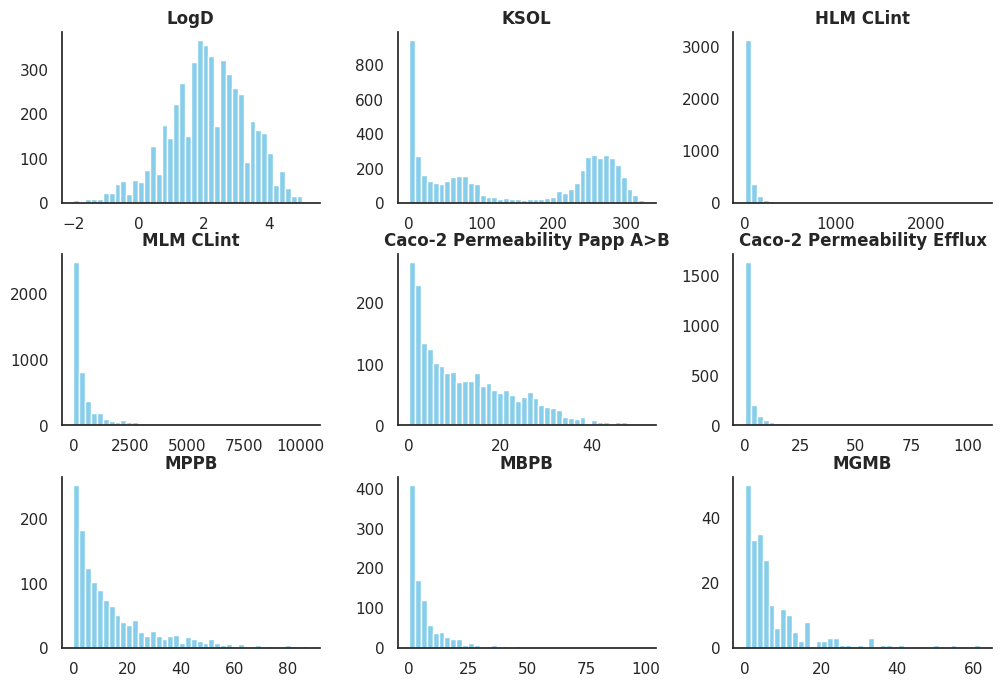

In [4]:
###First, checking histogram of variables###
axes = raw_data.hist(
    bins=40, 
    grid=False, 
    figsize=(12, 8), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=1.0,
    layout=(3, 3)
)

for ax in axes.flatten():
    ax.set_title(ax.get_title(), fontweight='bold', fontsize=12)
    sns.despine(ax=ax)

#And check ranges of data
raw_data.describe()

# Verify Assumption of Drug-Likeness (Lipinskis Rule of 5)

In [3]:
df_lipinski = raw_data.copy()

df_lipinski['Mol Weight'] = raw_data['SMILES'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x))) #molecular weight less than 500 daltons
df_lipinski['Hbonding Donors'] = raw_data['SMILES'].apply(lambda x: Descriptors.NumHDonors(Chem.MolFromSmiles(x))) #No more than 5 Hbond Donors
df_lipinski['Hbonding Acceptors'] = raw_data['SMILES'].apply(lambda x: Descriptors.NumHAcceptors(Chem.MolFromSmiles(x))) #No more than 10 Hbond Acceptors
df_lipinski['LogP'] = raw_data['SMILES'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x))) #LogP does not exceed 5

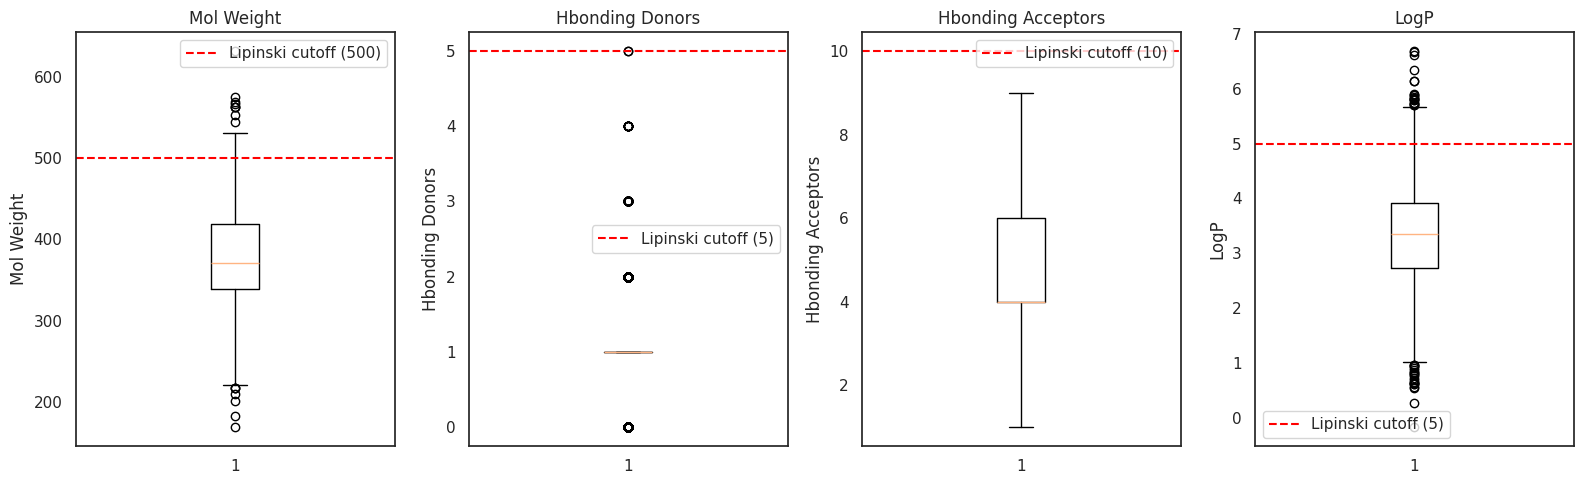

Outlier Summary:
  Mol Weight: 34 outliers
  Hbonding Donors: 0 outliers
  Hbonding Acceptors: 0 outliers
  LogP: 175 outliers


In [30]:
#####################################Boxplot of each Lipinski criteria with red line denoted cutoff for each statistic###############################

outliers = {}  # Dictionary to store outliers of each rule, for later analysis

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

cols = ['Mol Weight', 'Hbonding Donors', 'Hbonding Acceptors', 'LogP']
cutoffs = {'Mol Weight': 500, 'Hbonding Donors': 5, 'Hbonding Acceptors': 10, 'LogP': 5}

for ax, col in zip(axes, cols):
    ax.boxplot(df_lipinski[col].dropna())
    ax.axhline(y=cutoffs[col], color='red', linestyle='--', label=f'Lipinski cutoff ({cutoffs[col]})')
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.legend()

    # Store outliers
    mask = df_lipinski[col] > cutoffs[col]
    outliers[col] = df_lipinski['SMILES'][mask]

plt.tight_layout()
plt.show()

# Print summary
print('Outlier Summary:')
for col, smiles in outliers.items():
    print(f"  {col}: {len(smiles)} outliers")

Some compounds exceed the cutoff of Molecular Weight and LogP values for Lipinski's Rule of 5 criteria. In this case, since the violations are modest and the training data is small, they will be left in the dataset. 

It may also be the case that they are 'Beyond Rule of 5' drugs, which have become more common recently. 

# Lets check the structures of the outliers:

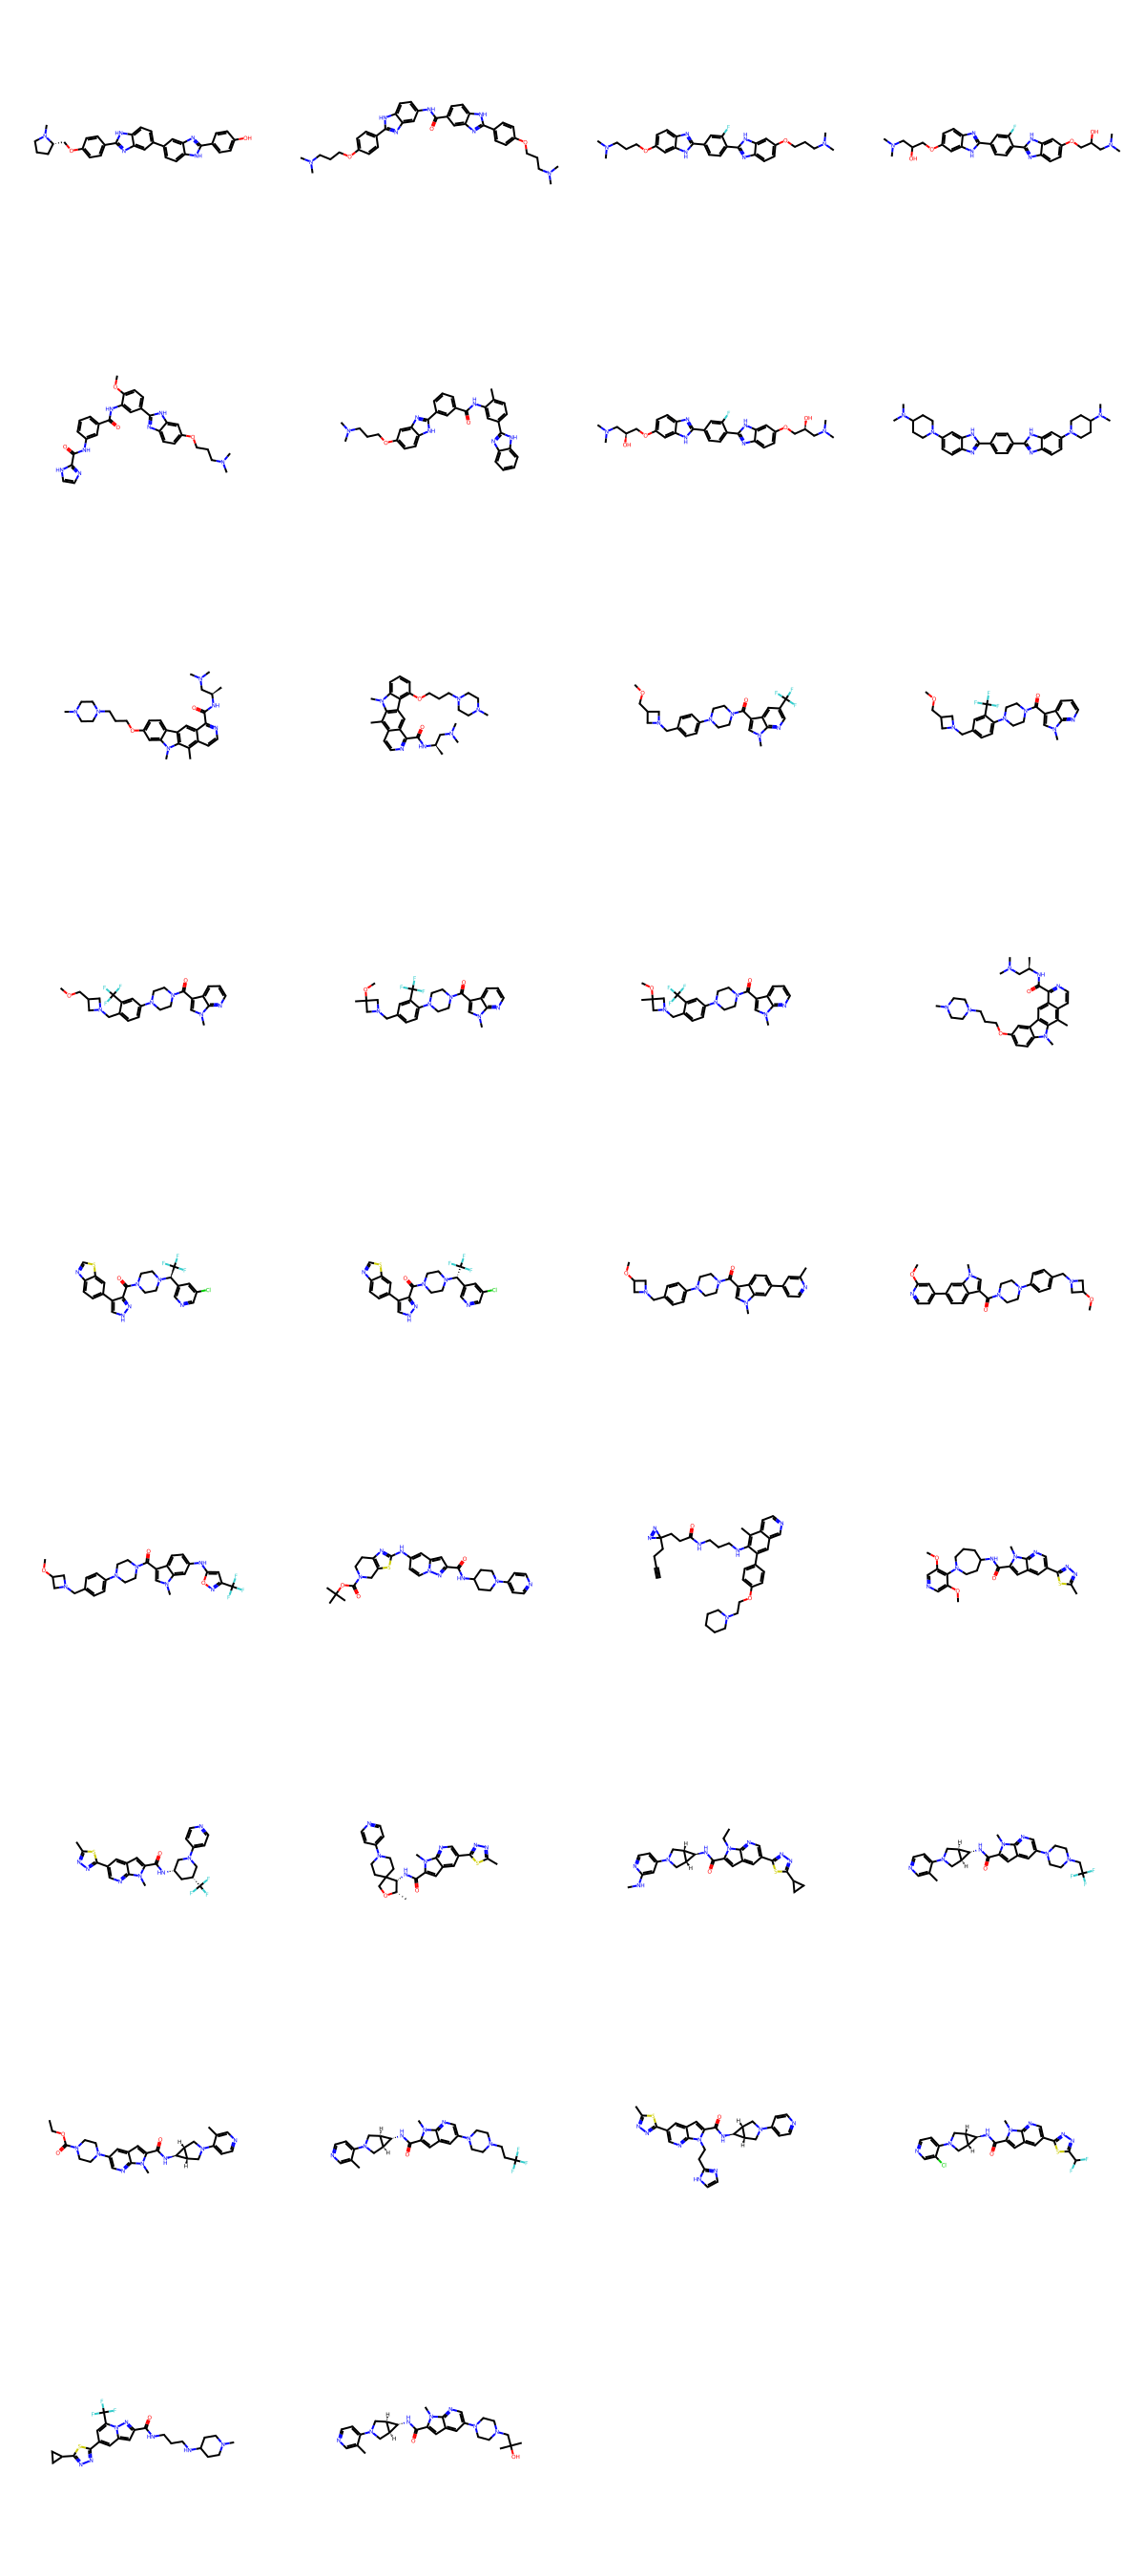

In [53]:
# -- Checking Structure of Molecular Weight Outliers --
mols = [Chem.MolFromSmiles(s) for s in outliers['Mol Weight']]
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(300, 300))
display(img)

### The outlier molecules are relatively large, but look visually reasonable